### Introdução da estratégia mostrando o cálculo dos fatores usando PCA

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import bs4 as bs
import requests
import seaborn as sns

In [3]:
# Pegando todos os tickers do S&P500
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

resp = requests.get(url, headers=headers)
soup = bs.BeautifulSoup(resp.text, "lxml")

table = soup.find("table", {"id": "constituents"})  # tabela principal
tickers = []
for row in table.find_all("tr")[1:]:
    ticker = row.find_all("td")[0].text.strip()
    tickers.append(ticker)

print(len(tickers))
tickers[:10]

503


['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']

In [4]:
soup

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" dir="ltr" lang="en">
<head>
<meta charset="utf-8"/>
<title>List of S&amp;P 500 companies - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-ena

In [5]:
# Salvar para uso futuro
# data.to_csv("dados_2006_2007.csv")
# data_full.to_csv("dados_full_1997_2007.csv")

# Carregar de volta os DataFrames
data = pd.read_csv("dados_2006_2007.csv", index_col=0)
data_full = pd.read_csv("dados_full_1997_2007.csv", index_col=0)

data.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-03,37.081554,4.466237,12.043587,20.727745,38.520000,32.400002,10.594823,14.750937,20.099945,34.221115,...,11.519892,12.624353,13.915197,8.324624,62.774391,29.063992,9.076951,11.604429,42.830002,59.318130
2006-01-04,36.894062,4.490475,12.061853,20.840931,38.419998,32.560001,11.046078,14.833292,20.153954,33.830730,...,11.907521,12.929352,13.615330,8.376866,63.426331,29.010111,9.120948,11.703715,42.410000,59.881199
2006-01-05,36.556564,4.448054,12.217161,20.996571,38.070000,33.680000,10.941438,14.953656,20.681955,33.537945,...,11.792445,12.815693,13.455825,8.289795,62.465599,28.837721,9.116057,12.202647,42.529999,59.248848
2006-01-06,36.856548,4.600769,12.451636,22.036495,39.000000,33.779999,11.118018,15.488960,20.789953,34.318710,...,12.052885,12.834639,13.551529,8.321144,61.710709,29.112469,9.150276,12.167894,44.119999,58.945679
2006-01-09,37.039364,4.757119,12.914498,21.972822,38.380001,33.250000,10.928356,15.561815,20.729950,33.882401,...,12.803918,12.804323,13.889677,8.456985,64.215538,30.486212,9.125833,12.262219,44.790001,61.033234


In [6]:
# Baixar dados históricos

# substituir 'BRK.B' por 'BRK-B' )em todos os casos)
# def download_one_ticker(ticker, start, end, max_retries=3, delay=5):
#     for attempt in range(max_retries):
#         try:
#             sanitized = ticker.replace(".", "-")
#             df = yf.download(sanitized, start=start, end=end, auto_adjust=True,
#                              progress=False, threads=False, timeout=30)
            
#             if not df.empty:
#                 return df["Close"]
#             else:
#                 return None
                
#         except Exception as e:
#             err_msg = str(e)
#             print(err_msg)
            
#             # Outros erros → re-tenta
#             time.sleep(delay)

#     return None

# start_date_full = "1997-01-02"
# start_date = "2006-01-02"
# end_date = "2007-12-31"

# dict_data = {}
# dict_data_full = {}
# data_fail = []
# data_full_fail = []

# for ticker in tickers:
#     data_ticker = download_one_ticker(ticker, start_date, end_date)
#     print(ticker)
#     if data_ticker is not None:
#         dict_data[ticker] = data_ticker
#     else:
#         data_fail.append(ticker)

#     data_ticker_full = download_one_ticker(ticker, start_date_full, end_date)
#     if data_ticker_full is not None:
#         dict_data_full[ticker] = data_ticker_full
#     else:
#         data_full_fail.append(ticker)

# # Construir DataFrames
# data = pd.concat(dict_data.values(), axis=1)
# data.columns = dict_data.keys()

# data_full = pd.concat(dict_data_full.values(), axis=1)
# data_full.columns = dict_data_full.keys()
# data.head()

# Salvar para uso futuro
# data.to_csv("dados_2006_2007.csv")
# data_full.to_csv("dados_full_1997_2007.csv")

In [7]:
data_full.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
1997-01-02,16.557707,1.968471,5.582990,NaN,4.734612,13.5625,7.418822,3.155401,NaN,16.411493,...,16.618135,6.832459,2.766412,4.945475,NaN,NaN,6.785948,NaN,10.333333,NaN
1997-01-03,16.269735,1.951929,5.707674,NaN,4.795902,14.0000,7.398389,3.164598,NaN,16.682497,...,17.337374,6.832459,2.871087,5.030447,NaN,NaN,6.804489,NaN,10.722222,NaN
1997-01-06,16.293749,1.927117,5.638408,NaN,4.964448,14.2500,7.602765,3.201397,NaN,16.772840,...,18.094467,6.923078,2.701612,5.098424,NaN,NaN,6.841564,NaN,10.888889,NaN
1997-01-07,16.101763,1.985012,5.763087,NaN,5.163639,14.9375,7.684513,3.182998,NaN,16.712626,...,18.018759,7.013696,2.781365,5.200393,NaN,NaN,6.878650,NaN,11.888889,NaN
1997-01-08,16.077774,1.976740,5.679964,NaN,5.178961,14.4375,7.745826,3.201397,NaN,16.802959,...,18.737999,7.068061,2.721551,5.251379,NaN,NaN,6.952816,NaN,11.666667,NaN


In [8]:
start_date_full = "1997-01-02"
start_date = "2006-01-02"
end_date = "2007-12-31"

data_spy = yf.download("SPY", start=start_date, end=end_date, auto_adjust=True)["Close"]
data_spy_full = yf.download("SPY", start=start_date_full, end=end_date, auto_adjust=True)["Close"]

data_spy.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
2006-01-03,87.721710
2006-01-04,88.137161
2006-01-05,88.192497
2006-01-06,88.926422
2006-01-09,89.154884


In [9]:
# Calcular retornos diários
returns = data.pct_change()
returns.dropna(inplace=True,axis=0, how='all')
returns.dropna(inplace=True,axis=1, how='any')

returns_full = data_full.pct_change()
returns_full.dropna(inplace=True,axis=0, how='all')
returns_full.dropna(inplace=True,axis=1, how='any')

returns_spy = data_spy.pct_change()
returns_spy.dropna(inplace=True,axis=0, how='all')
returns_spy.dropna(inplace=True,axis=1, how='any')

returns_spy_full = data_spy_full.pct_change()
returns_spy_full.dropna(inplace=True,axis=0, how='all')
returns_spy_full.dropna(inplace=True,axis=1, how='any')

returns.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-04,-0.005056,0.005427,0.001517,0.005461,-0.002596,0.004938,0.042592,0.005583,0.002687,-0.011408,...,0.033649,0.024160,-0.021550,0.006276,0.010385,-0.001854,0.004847,0.008556,-0.009806,0.009492
2006-01-05,-0.009148,-0.009447,0.012876,0.007468,-0.009110,0.034398,-0.009473,0.008114,0.026198,-0.008654,...,-0.009664,-0.008791,-0.011715,-0.010394,-0.015147,-0.005942,-0.000536,0.042630,0.002829,-0.010560
2006-01-06,0.008206,0.034333,0.019192,0.049528,0.024429,0.002969,0.016139,0.035798,0.005222,0.023280,...,0.022085,0.001478,0.007112,0.003782,-0.012085,0.009527,0.003754,-0.002848,0.037385,-0.005117
2006-01-09,0.004960,0.033984,0.037173,-0.002889,-0.015897,-0.015690,-0.017059,0.004704,-0.002886,-0.012713,...,0.062311,-0.002362,0.024953,0.016325,0.040590,0.047187,-0.002671,0.007752,0.015186,0.035415
2006-01-10,-0.006201,0.023949,-0.009667,-0.021571,0.005993,0.050526,-0.006583,0.000814,0.013024,-0.011522,...,0.008988,0.013315,0.019063,0.008648,-0.010153,0.001237,0.004821,-0.000810,0.037285,-0.004258


In [10]:
returns_full.head()

,MMM,AOS,ABT,ADBE,AMD,AES,AFL,APD,ALB,LNT,...,WEC,WFC,WELL,WST,WDC,WY,WSM,WMB,XEL,ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
1997-01-03,-0.017392,-0.008404,0.022333,0.012945,0.032258,-0.002754,0.002915,0.016513,-0.019608,0.004464,...,0.004673,0.020232,0.015544,-0.004465,0.043280,0.000000,0.037838,0.017182,0.002732,0.037634
1997-01-06,0.001476,-0.012712,-0.012136,0.035144,0.017857,0.027624,0.011628,0.005415,0.020000,0.004444,...,0.004651,-0.011332,-0.005103,-0.004484,0.043668,0.013263,-0.059028,0.013513,0.005449,0.015544
1997-01-07,-0.011783,0.030043,0.022112,0.040124,0.048246,0.010752,-0.005747,-0.003590,-0.006536,-0.004424,...,0.000000,0.011462,-0.010256,0.009009,-0.004184,0.013089,0.029521,0.020000,0.005421,0.091837
1997-01-08,-0.001490,-0.004167,-0.014423,0.002967,-0.033473,0.007979,0.005780,0.005405,-0.019736,0.000000,...,0.009259,0.005666,-0.010363,-0.008929,0.039916,0.007751,-0.021506,0.009804,0.010782,-0.018692
1997-01-09,-0.001493,-0.004183,0.009757,-0.020710,-0.047619,0.002638,-0.008621,-0.001792,0.013422,0.004444,...,0.018349,0.000000,0.020942,0.000000,0.020202,-0.002564,0.069597,0.019418,0.002666,0.038095


In [11]:
display(returns.mean())
returns.std()

MMM     0.000308
AOS     0.000229
ABT     0.000904
ACN     0.000624
ADBE    0.000380
          ...   
WYNN    0.002061
XEL     0.000637
YUM     0.001165
ZBRA   -0.000277
ZBH     0.000058
Length: 401, dtype: float64

MMM     0.011614
AOS     0.021684
ABT     0.011357
ACN     0.015595
ADBE    0.018172
          ...   
WYNN    0.024934
XEL     0.011289
YUM     0.014912
ZBRA    0.016741
ZBH     0.015221
Length: 401, dtype: float64

In [12]:
# Padronização dos retornos
mu_i = returns.mean()
sigma_i = returns.std()
Y = (returns - mu_i)/sigma_i

Y_full = (returns_full - returns_full.mean())/returns_full.std()
Y.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-04,-0.461878,0.239719,0.053949,0.310115,-0.163758,0.266527,2.475811,0.360302,0.126865,-0.926952,...,1.313273,1.450880,-1.016625,0.317422,0.891303,-0.156992,0.372987,0.495668,-0.569213,0.619778
2006-01-05,-0.814174,-0.446200,1.054126,0.438830,-0.522195,1.312046,-0.602965,0.548333,1.487035,-0.725009,...,-0.440285,-0.566695,-0.535176,-0.690914,-1.347440,-0.320968,-0.103888,2.780752,0.185557,-0.697608
2006-01-06,0.680049,1.572763,1.610278,3.135792,1.323373,0.196640,0.911539,2.604630,0.273509,1.617266,...,0.845119,0.062090,0.386522,0.166566,-1.078932,0.299467,0.276128,-0.269095,2.249678,-0.340005
2006-01-09,0.400571,1.556657,3.193457,-0.225300,-0.895706,-0.465556,-1.051546,0.294980,-0.195551,-1.022724,...,2.473709,-0.173056,1.259890,0.925283,3.539677,1.809869,-0.293032,0.441756,0.923640,2.322811
2006-01-10,-0.560461,1.093883,-0.930814,-1.423176,0.308870,1.884436,-0.432047,0.006021,0.724887,-0.935308,...,0.314858,0.786886,0.971535,0.460952,-0.909505,-0.033035,0.370650,-0.132415,2.243686,-0.283571


In [13]:
# Calculando a matriz de correlação
corr_matrix = Y.corr()
corr_matrix_full = Y_full.corr()

corr_matrix.head()

,MMM,AOS,ABT,ACN,ADBE,AMD,AES,AFL,A,APD,...,WDC,WY,WSM,WMB,WTW,WYNN,XEL,YUM,ZBRA,ZBH
MMM,1.000000,0.233619,0.247572,0.208137,0.242898,0.175017,0.253135,0.336264,0.376593,0.439362,...,0.236260,0.374135,0.298393,0.272090,0.198559,0.236657,0.314496,0.299767,0.254541,0.203041
AOS,0.233619,1.000000,0.208440,0.265482,0.200147,0.203088,0.215252,0.233831,0.228672,0.347641,...,0.275472,0.371026,0.287916,0.235934,0.201351,0.218885,0.263168,0.289694,0.254592,0.172077
ABT,0.247572,0.208440,1.000000,0.224951,0.200953,0.144945,0.257341,0.388110,0.280269,0.364763,...,0.192839,0.340281,0.200825,0.182499,0.168158,0.242761,0.430465,0.294046,0.178668,0.175146
ACN,0.208137,0.265482,0.224951,1.000000,0.195496,0.177217,0.217893,0.263749,0.276142,0.289141,...,0.177006,0.270911,0.196650,0.196379,0.160663,0.202361,0.134654,0.239480,0.225472,0.179565
ADBE,0.242898,0.200147,0.200953,0.195496,1.000000,0.254135,0.199260,0.315688,0.303717,0.374555,...,0.196084,0.233679,0.195029,0.204272,0.177361,0.201449,0.274756,0.258044,0.258183,0.212827


array([119.1646588 ,  11.98958756,  10.60027337,   8.21262456,
         6.06130293,   4.96469915,   4.27021991,   4.03841986,
         3.43355472,   3.21332004,   2.99232066,   2.91892176,
         2.6815643 ,   2.60727875,   2.57552732,   2.50523021,
         2.42241366,   2.37414898,   2.30285389,   2.2690471 ])

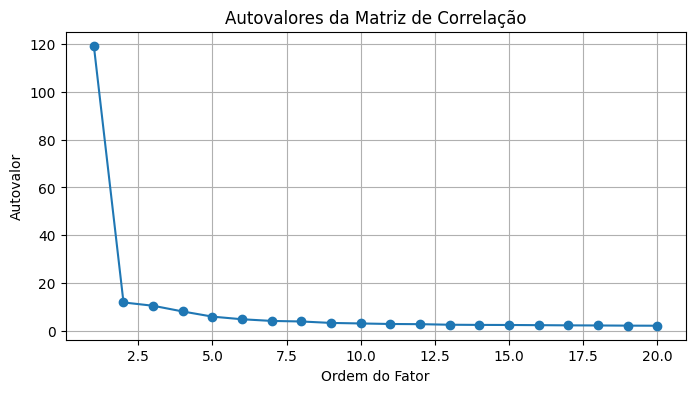

In [14]:
# PCA sobre matriz de correlação empírica
evals, evecs = np.linalg.eigh(corr_matrix)         
idx = np.argsort(evals)[::-1]                      
eigen_val  = evals[idx]
eigen_vec  = evecs[:, idx]                          

evals_f, evecs_f = np.linalg.eigh(corr_matrix_full)
idx_f = np.argsort(evals_f)[::-1]
eigen_val_full = evals_f[idx_f]
eigen_vec_full = evecs_f[:, idx_f]

display(eigen_val[:20])

# --- Visualização dos 20 maiores autovalores
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, min(20, len(eigen_val)) + 1), eigen_val[:20], 'o-')
plt.title("Autovalores da Matriz de Correlação")
plt.xlabel("Ordem do Fator")
plt.ylabel("Autovalor")
plt.grid(True)
plt.show()


(0.5, 25.0)

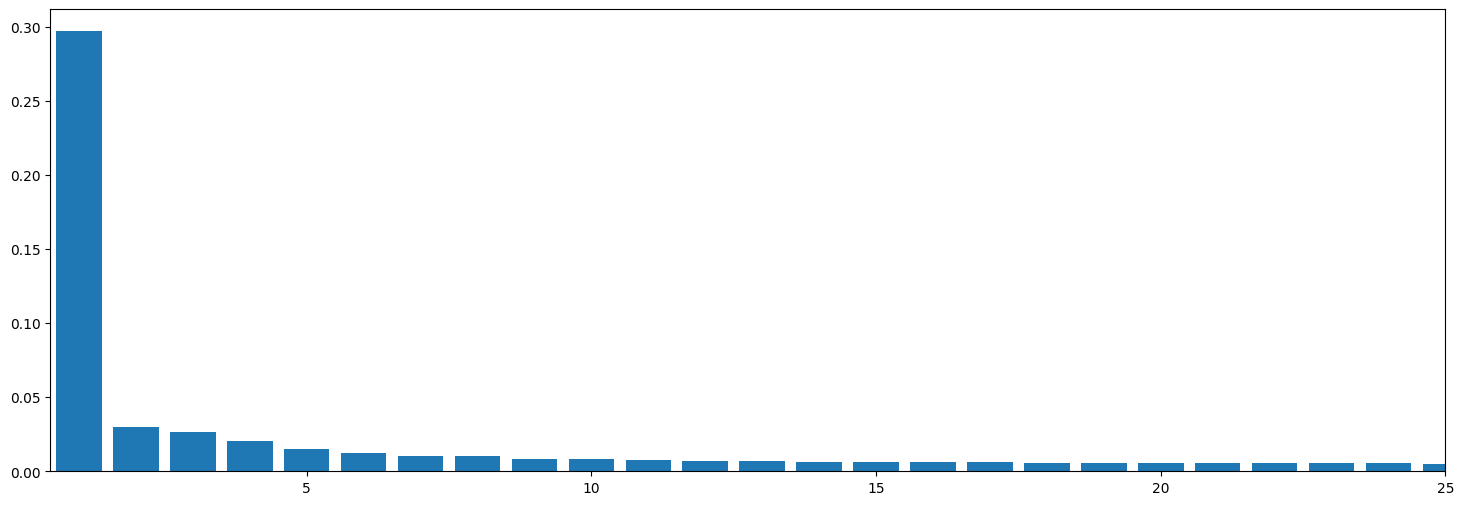

In [15]:
plt.figure(figsize=(18,6))
plt.bar(np.arange(1, len(eigen_val)+1),height = (eigen_val)/sum(eigen_val))
plt.xlim(0.5,25)
#plt.ylim(0,0.7)

In [16]:
# Pesos dos eigenportfólios
sigma = returns.std(ddof=1)
sigma_full = returns_full.std(ddof=1)

def eigen_weights(j):
    vj = pd.Series(eigen_vec[:, j], index=returns.columns)
    wj = vj / sigma
    wj = wj / wj.abs().sum()     # |w|=1 (controle de alavancagem)
    return wj

def eigen_weights_full(j):
    vj = pd.Series(eigen_vec_full[:, j], index=returns_full.columns)
    wj = vj / sigma_full
    wj = wj / wj.abs().sum()
    return wj

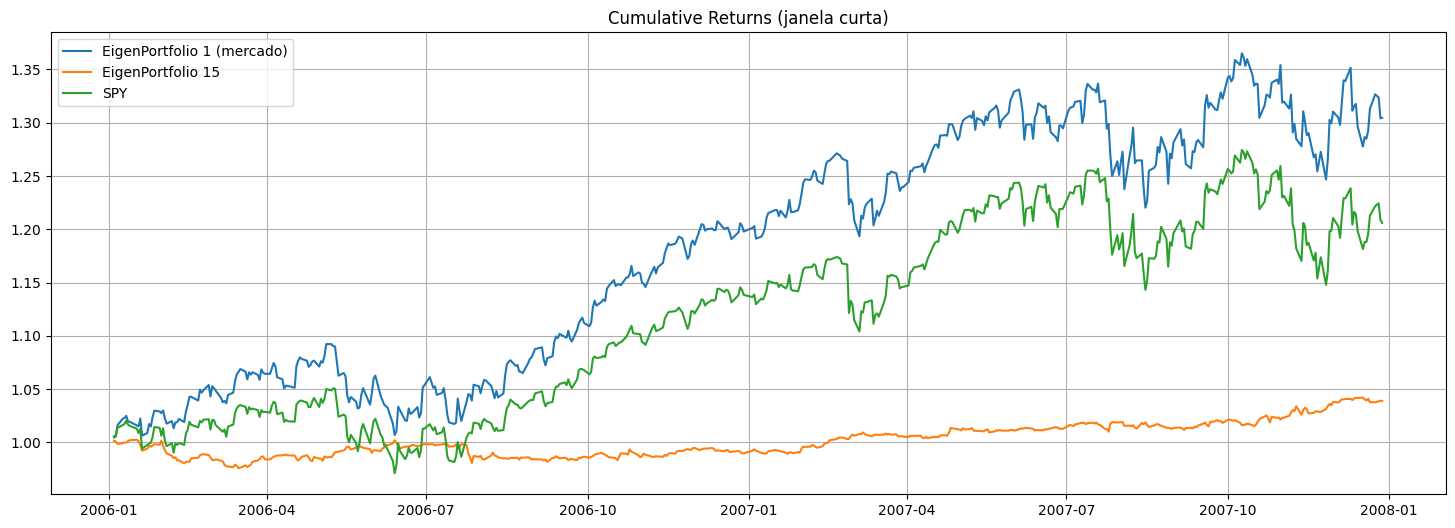

In [17]:
# Pesos do Eigenportifolio de mercado
w1  = eigen_weights(0)    # PC1 ~ "mercado"
w15 = eigen_weights(14)   # PC15

# --- Retornos diários dos fatores ---
F1  = returns.dot(w1) 
F15 = returns.dot(w15)

# --- Retornos acumulados
cum_F1  = (1 + F1).cumprod()
cum_F15 = (1 + F15).cumprod()
cum_SPY = (1 + returns_spy).cumprod()

if isinstance(cum_SPY, pd.DataFrame):
    # tente pelo rótulo; ajuste conforme seu DF
    cum_SPY = cum_SPY['SPY'] if 'SPY' in cum_SPY.columns else cum_SPY.iloc[:, 0]

# --- Garantir DatetimeIndex sem timezone ---
for s in (cum_F1, cum_F15, cum_SPY):
    s.index = pd.to_datetime(s.index).tz_localize(None)
    
# --- Plot ---
plt.figure(figsize=(18,6))
plt.plot(cum_F1,  label='EigenPortfolio 1 (mercado)')
plt.plot(cum_F15, label='EigenPortfolio 15')
plt.plot(cum_SPY, label='SPY')
plt.legend(); plt.grid(True); plt.title('Cumulative Returns (janela curta)')
plt.show()

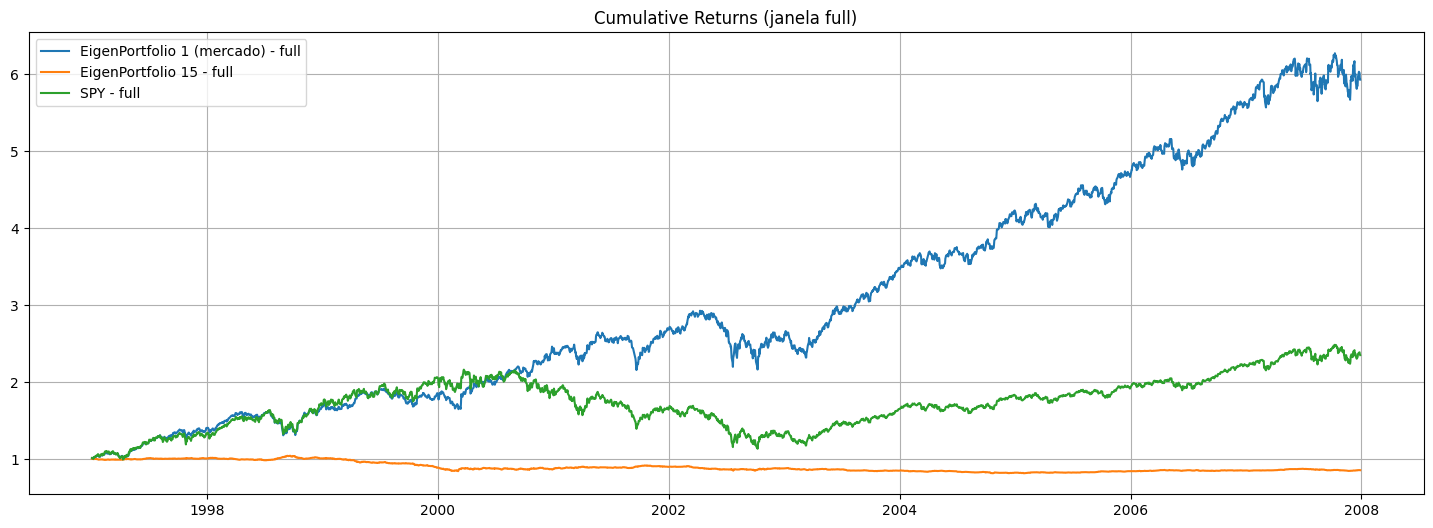

In [18]:
w1_full  = eigen_weights_full(0)
w15_full = eigen_weights_full(14)

F1_full  = returns_full.dot(w1_full)
F15_full = returns_full.dot(w15_full)

cum_F1_full  = (1 + F1_full).cumprod()
cum_F15_full = (1 + F15_full).cumprod()
cum_SPY_full = (1 + returns_spy_full).cumprod()

if isinstance(cum_SPY_full, pd.DataFrame):
    # tente pelo rótulo; ajuste conforme seu DF
    cum_SPY_full = cum_SPY_full['SPY'] if 'SPY' in cum_SPY_full.columns else cum_SPY_full.iloc[:, 0]

# --- Garantir DatetimeIndex sem timezone ---
for s in (cum_F1_full, cum_F15_full, cum_SPY_full):
    s.index = pd.to_datetime(s.index).tz_localize(None)
    
plt.figure(figsize=(18,6))
plt.plot(cum_F1_full,  label='EigenPortfolio 1 (mercado) - full')
plt.plot(cum_F15_full, label='EigenPortfolio 15 - full')
plt.plot(cum_SPY_full, label='SPY - full')
plt.legend(); plt.grid(True); plt.title('Cumulative Returns (janela full)')
plt.show()